In [ ]:
# ============================================================
# SECTION 1 — INSTALL LIBRARIES
# ============================================================

!pip install transformers datasets accelerate evaluate -q
!pip install nltk wordcloud seaborn joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# SECTION 2 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import string
import nltk
import time

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from nltk.corpus import stopwords

import torch

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

import joblib

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:

# SECTION 3 — LOAD DATASET (FIXED)

df = pd.read_csv('train.csv', on_bad_lines='skip', engine='python')

print("Dataset loaded successfully!")
print(f"Rows loaded: {len(df)}")
print(df.head())


Dataset loaded successfully!
Rows loaded: 159571
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [ ]:

# SECTION 4 — UNDERSTAND DATASET


print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

toxic_columns = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

print("\nToxicity Counts:")
print(df[toxic_columns].sum())


Dataset Shape:
(159571, 8)

Columns:
Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

Missing Values:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Toxicity Counts:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


In [ ]:

# SECTION 5 — CREATE 5-LEVEL TOXICITY SYSTEM (IMPROVED)


def toxicity_level(row):

    text = str(row['comment_text']).lower()

    # EXTREME TOXICITY (REAL THREAT KEYWORDS + LABEL)

    extreme_keywords = [
        "kill you", "i will kill", "die", "murder", "rape", "bomb you"
    ]

    if any(kw in text for kw in extreme_keywords):
        return 'extreme'

    if row['threat'] == 1:
        return 'extreme'

    # SEVERE TOXICITY (HATE / SEVERE TOXIC)

    if row['identity_hate'] == 1 or row['severe_toxic'] == 1:
        return 'severe'

    # MODERATE TOXICITY (OBSCENE)

    if row['obscene'] == 1:
        return 'moderate'

    # MILD TOXICITY (INSULT / TOXIC)

    if row['insult'] == 1 or row['toxic'] == 1:
        return 'mild'

    # CLEAN

    return 'clean'


df['toxicity_level'] = df.apply(toxicity_level, axis=1)

print("\nToxicity Level Distribution:")
print(df['toxicity_level'].value_counts())


Toxicity Level Distribution:
toxicity_level
clean       139439
mild          6909
moderate      5845
extreme       5023
severe        2355
Name: count, dtype: int64


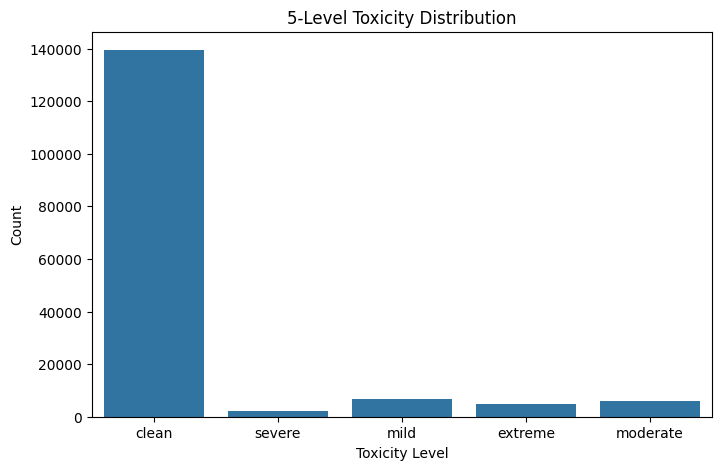

In [ ]:

# SECTION 6 — VISUALIZE TOXICITY DISTRIBUTION


plt.figure(figsize=(8,5))

sns.countplot(x=df['toxicity_level'])

plt.title('5-Level Toxicity Distribution')

plt.xlabel('Toxicity Level')

plt.ylabel('Count')

plt.show()

In [ ]:

# SECTION 7 — TEXT CLEANING


stop_words = set(stopwords.words('english'))

leet_dict = {
    '0': 'o',
    '1': 'i',
    '3': 'e',
    '4': 'a',
    '5': 's',
    '7': 't',
    '@': 'a',
    '$': 's'
}


def normalize_leetspeak(text):

    for key, value in leet_dict.items():

        text = text.replace(key, value)

    return text


def clean_text(text):

    text = str(text).lower()

    # Remove HTML
    text = re.sub(r'<.*?>', '', text)

    # Normalize leetspeak
    text = normalize_leetspeak(text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)



In [ ]:

# SECTION 8 — APPLY CLEANING


print("Cleaning text...")

df['clean_text'] = df['comment_text'].apply(
    clean_text
)

print(df[['comment_text', 'clean_text']].head())




Cleaning text...
                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                          clean_text  
0  explanation edits made username hardcore metal...  
1  daww matches background colour im seemingly st...  
2  hey man im really trying edit war guy constant...  
3  cant make real suggestions improvement wondere...  
4                sir hero chance remember page thats  


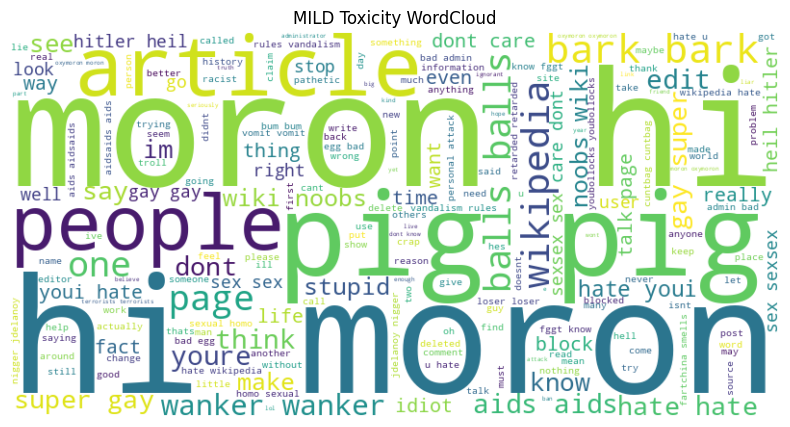

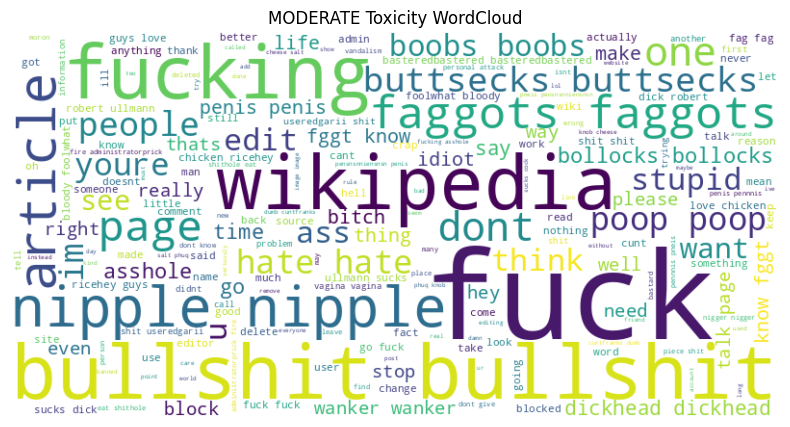

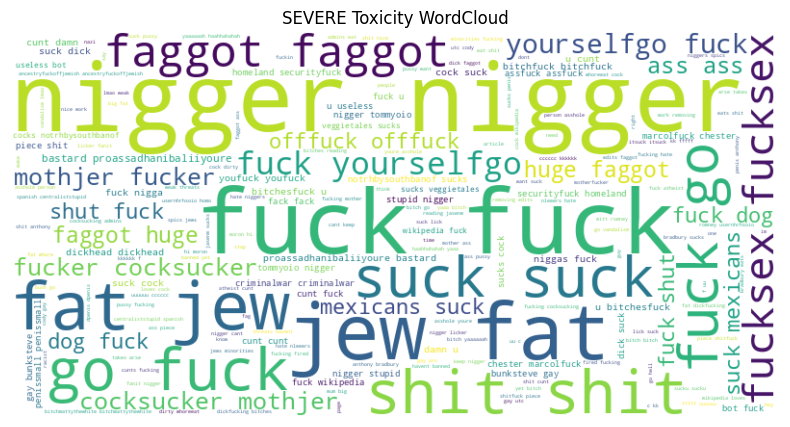

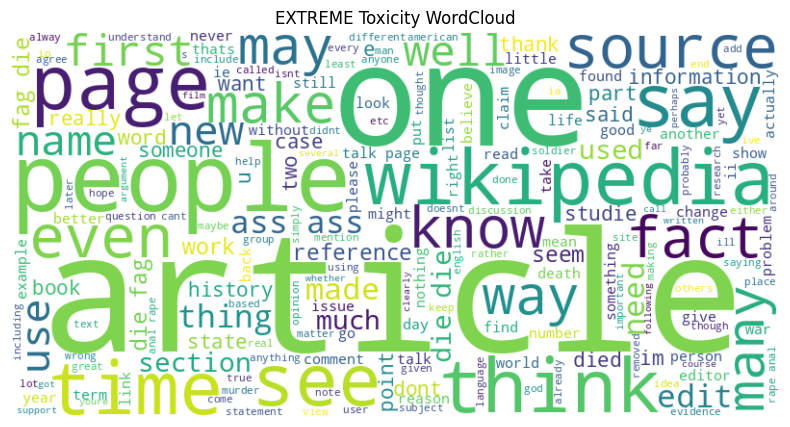

In [ ]:

# SECTION 9 — WORD CLOUDS


levels = [
    'mild',
    'moderate',
    'severe',
    'extreme'
]

for level in levels:

    text = ' '.join(
        df[
            df['toxicity_level'] == level
        ]['clean_text'].astype(str)
    )

    if len(text.strip()) > 0:

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white'
        ).generate(text)

        plt.figure(figsize=(10,5))

        plt.imshow(
            wordcloud,
            interpolation='bilinear'
        )

        plt.axis('off')

        plt.title(f'{level.upper()} Toxicity WordCloud')

        plt.show()


In [ ]:

# SECTION 10 — LABEL ENCODING


label_encoder = LabelEncoder()

df['encoded_label'] = label_encoder.fit_transform(
    df['toxicity_level']
)

print("\nEncoded Labels:")

for i, label in enumerate(label_encoder.classes_):

    print(i, "=", label)




Encoded Labels:
0 = clean
1 = extreme
2 = mild
3 = moderate
4 = severe


In [ ]:

# SECTION 11 — TRAIN TEST SPLIT


X = df['clean_text']

y = df['encoded_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))

print("Testing Samples:", len(X_test))




Training Samples: 127656
Testing Samples: 31915


In [ ]:

# SECTION 12 — TF-IDF VECTORIZATION


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF Shape:")

print(X_train_tfidf.shape)



TF-IDF Shape:
(127656, 10000)


In [ ]:

# SECTION 13 — TRAIN NAIVE BAYES


start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_training_time = time.time() - start_time

print("\nNaive Bayes Training Time:")

print(nb_training_time)




Naive Bayes Training Time:
0.03078913688659668



Naive Bayes Results
Accuracy: 0.8959423468588438
Precision: 0.8748872181520847
Recall: 0.8959423468588438
F1 Score: 0.8617232134514297

Classification Report:

              precision    recall  f1-score   support

       clean       0.91      1.00      0.95     27888
     extreme       0.94      0.10      0.18      1005
        mild       0.40      0.05      0.10      1382
    moderate       0.56      0.44      0.49      1169
      severe       0.89      0.07      0.13       471

    accuracy                           0.90     31915
   macro avg       0.74      0.33      0.37     31915
weighted avg       0.87      0.90      0.86     31915



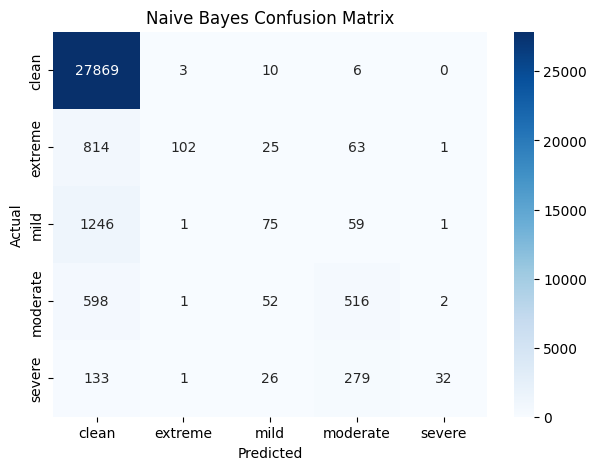

In [ ]:

# SECTION 14 — EVALUATE NAIVE BAYES


nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average='weighted'
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average='weighted'
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average='weighted'
)

print("\nNaive Bayes Results")

print("Accuracy:", nb_accuracy)

print("Precision:", nb_precision)

print("Recall:", nb_recall)

print("F1 Score:", nb_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Naive Bayes Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


In [ ]:

# SECTION 15 — TRAIN RANDOM FOREST


start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_training_time = time.time() - start_time

print("\nRandom Forest Training Time:")

print(rf_training_time)




Random Forest Training Time:
462.5456717014313



Random Forest Results
Accuracy: 0.9237975873413755
Precision: 0.909248833218268
Recall: 0.9237975873413755
F1 Score: 0.9112307561035227

Classification Report:

              precision    recall  f1-score   support

       clean       0.95      0.99      0.97     27888
     extreme       0.97      0.66      0.79      1005
        mild       0.47      0.18      0.26      1382
    moderate       0.61      0.68      0.64      1169
      severe       0.54      0.24      0.33       471

    accuracy                           0.92     31915
   macro avg       0.71      0.55      0.60     31915
weighted avg       0.91      0.92      0.91     31915



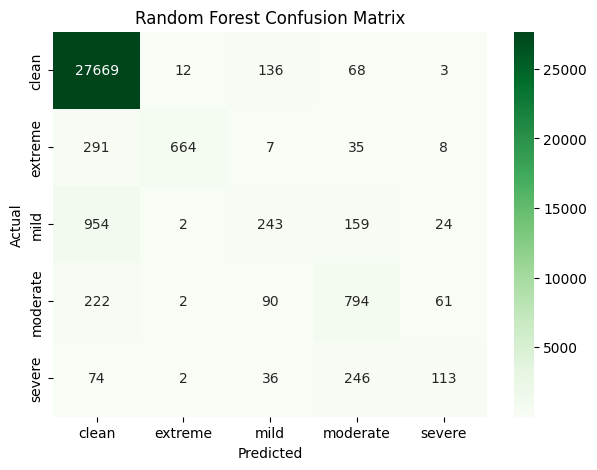

In [ ]:

# SECTION 16 — EVALUATE RANDOM FOREST


rf_predictions = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print("\nRandom Forest Results")

print("Accuracy:", rf_accuracy)

print("Precision:", rf_precision)

print("Recall:", rf_recall)

print("F1 Score:", rf_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()



In [ ]:

# SECTION 17 — PREPARE DATA FOR DISTILBERT


bert_df = df.sample(
    10000,
    random_state=42
)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    bert_df['clean_text'].tolist(),
    bert_df['encoded_label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=bert_df['encoded_label']
)




In [ ]:

# SECTION 18 — TOKENIZATION


tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding='max_length',
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding='max_length',
    max_length=128
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:

# SECTION 19 — CREATE DATASET (IMPROVED + CLEAN LABEL FORMAT)


bert_df = df.sample(10000, random_state=42)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    bert_df['clean_text'].tolist(),
    bert_df['encoded_label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=bert_df['encoded_label']
)

# convert to int explicitly (VERY IMPORTANT FIX)
train_labels = [int(x) for x in train_labels]
test_labels = [int(x) for x in test_labels]

In [ ]:

# SECTION 20 — LOAD DISTILBERT MODEL


bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5
)




config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',

    num_train_epochs=5,   # 🔥 increased from 2 → FIX UNDERFITTING

    learning_rate=2e-5,   # 🔥 better DistilBERT tuning

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    warmup_steps=500,

    weight_decay=0.01,

    logging_dir='./logs',
    logging_steps=50,

    eval_strategy='epoch',  # FIX (correct parameter)

    save_strategy='no'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:

# SECTION 22 — METRICS FUNCTION (IMPROVED)


def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='macro'),
        'recall': recall_score(labels, preds, average='macro'),
        'f1': f1_score(labels, preds, average='macro')
    }

In [ ]:

# NEW STEP: CONVERT ENCODINGS TO DATASET OBJECTS


# This creates the actual 'train_dataset' variable the Trainer is looking for
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels
})

# This creates the 'test_dataset'
test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels
})

print("Datasets ready for training!")

Datasets ready for training!


In [ ]:

# SECTION 23 — TRAIN DISTILBERT


trainer = Trainer(

    model=bert_model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

start_time = time.time()

trainer.train()

bert_training_time = time.time() - start_time

print("\nDistilBERT Training Time:")

print(bert_training_time)




Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.295539,0.325083,0.899000,0.456937,0.471980,0.443807
2,0.306726,0.337698,0.912000,0.575506,0.512451,0.514876
3,0.179219,0.354907,0.915500,0.690144,0.562573,0.574212
4,0.059596,0.379888,0.922000,0.700741,0.607812,0.636759
5,0.030259,0.403496,0.922500,0.701864,0.627025,0.656704


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



DistilBERT Training Time:
593.0874218940735


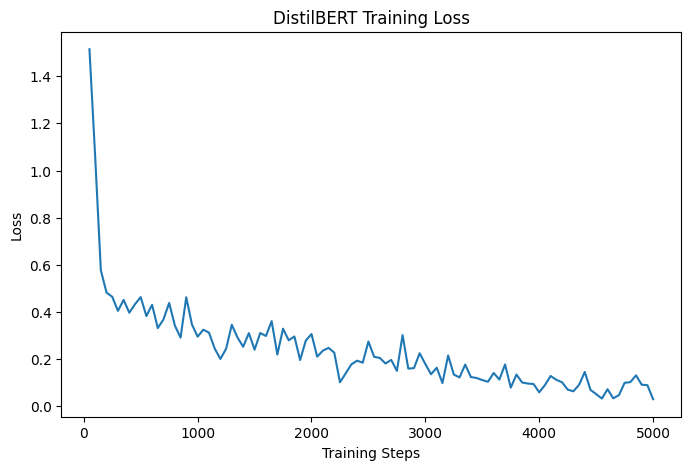

In [ ]:

# SECTION 24 — DISTILBERT LOSS GRAPH


logs = trainer.state.log_history

train_loss = []

steps = []

for log in logs:

    if 'loss' in log:

        train_loss.append(log['loss'])

        steps.append(log['step'])

plt.figure(figsize=(8,5))

plt.plot(
    steps,
    train_loss
)

plt.title('DistilBERT Training Loss')

plt.xlabel('Training Steps')

plt.ylabel('Loss')

plt.show()



In [ ]:

# SECTION 25 — EVALUATE DISTILBERT


bert_results = trainer.evaluate()

bert_accuracy = bert_results['eval_accuracy']

bert_precision = bert_results['eval_precision']

bert_recall = bert_results['eval_recall']

bert_f1 = bert_results['eval_f1']

print("\nDistilBERT Results")

print("Accuracy:", bert_accuracy)

print("Precision:", bert_precision)

print("Recall:", bert_recall)

print("F1 Score:", bert_f1)




DistilBERT Results
Accuracy: 0.9225
Precision: 0.7018643128308767
Recall: 0.6270252913220892
F1 Score: 0.6567043050956947



Classification Report:

              precision    recall  f1-score   support

       clean       0.96      0.98      0.97      1747
     extreme       0.77      0.52      0.62        66
        mild       0.43      0.39      0.41        83
    moderate       0.69      0.76      0.72        74
      severe       0.65      0.50      0.57        30

    accuracy                           0.92      2000
   macro avg       0.70      0.63      0.66      2000
weighted avg       0.92      0.92      0.92      2000



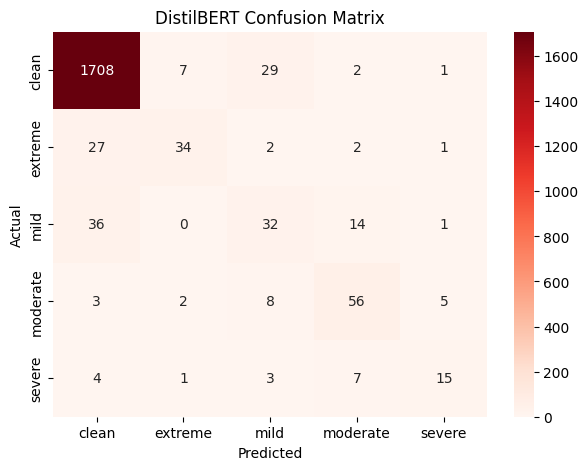

In [ ]:

# SECTION 26 — DISTILBERT CONFUSION MATRIX


predictions = trainer.predict(
    test_dataset
)

bert_preds = np.argmax(
    predictions.predictions,
    axis=1
)

print("\nClassification Report:\n")

print(
    classification_report(
        test_labels,
        bert_preds,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(
    test_labels,
    bert_preds
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('DistilBERT Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


In [ ]:

# SECTION 27 — MODEL COMPARISON TABLE


comparison_df = pd.DataFrame({

    'Model': [
        'Naive Bayes',
        'Random Forest',
        'DistilBERT'
    ],

    'Accuracy': [
        nb_accuracy,
        rf_accuracy,
        bert_accuracy
    ],

    'Precision': [
        nb_precision,
        rf_precision,
        bert_precision
    ],

    'Recall': [
        nb_recall,
        rf_recall,
        bert_recall
    ],

    'F1 Score': [
        nb_f1,
        rf_f1,
        bert_f1
    ],

    'Training Time': [
        nb_training_time,
        rf_training_time,
        bert_training_time
    ]
})

print("\nModel Comparison Table:\n")

print(comparison_df)



Model Comparison Table:

           Model  Accuracy  Precision    Recall  F1 Score  Training Time
0    Naive Bayes  0.895942   0.874887  0.895942  0.861723       0.030789
1  Random Forest  0.923798   0.909249  0.923798  0.911231     462.545672
2     DistilBERT  0.922500   0.701864  0.627025  0.656704     593.087422


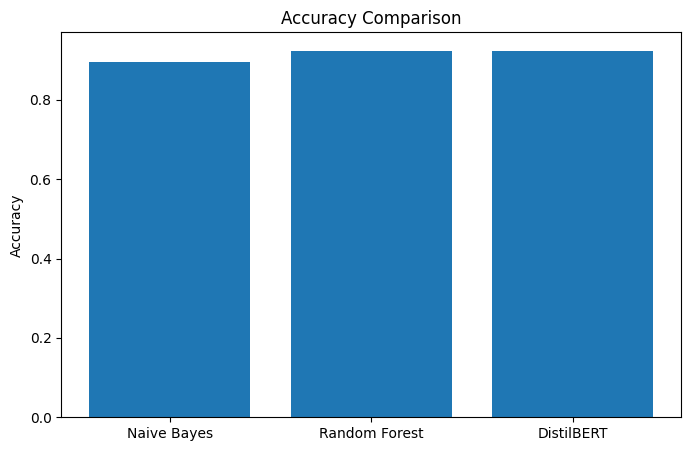

In [ ]:

# SECTION 28 — ACCURACY COMPARISON GRAPH


plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.title('Accuracy Comparison')

plt.ylabel('Accuracy')

plt.show()




In [ ]:

# SECTION 29 — PRECISION COMPARISON GRAPH


plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Precision']
)

plt.title('Precision Comparison')

plt.ylabel('Precision')

plt.show()



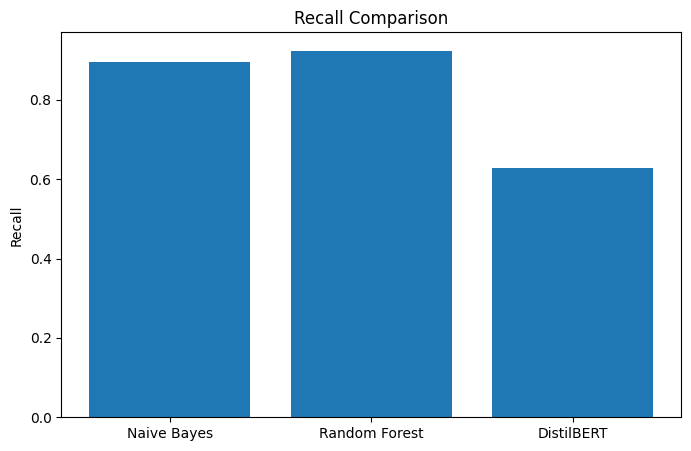

In [ ]:

# SECTION 30 — RECALL COMPARISON GRAPH


plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Recall']
)

plt.title('Recall Comparison')

plt.ylabel('Recall')

plt.show()



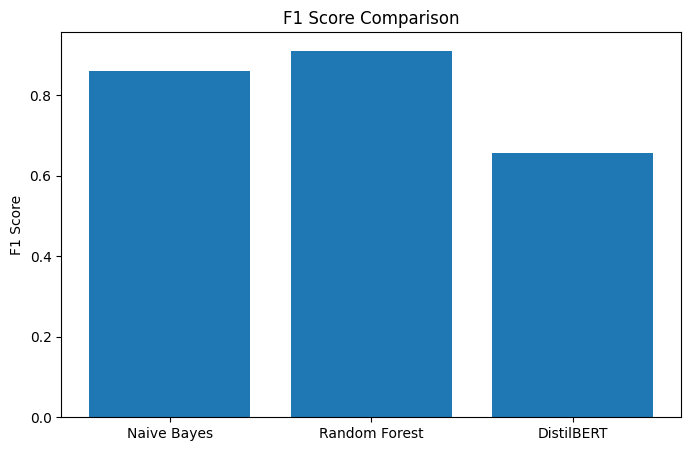

In [ ]:

# SECTION 31 — F1 SCORE COMPARISON GRAPH


plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['F1 Score']
)

plt.title('F1 Score Comparison')

plt.ylabel('F1 Score')

plt.show()


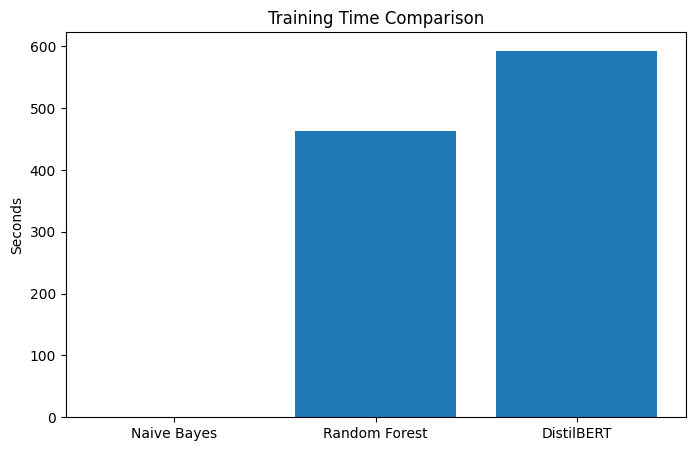

In [ ]:

# SECTION 32 — TRAINING TIME COMPARISON


plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Training Time']
)

plt.title('Training Time Comparison')

plt.ylabel('Seconds')

plt.show()


In [ ]:

# SECTION 33 — CHOOSE BEST MODEL USING ALL METRICS


# Create weighted final score
comparison_df['Final Score'] = (

    comparison_df['Accuracy'] * 0.25 +

    comparison_df['Precision'] * 0.20 +

    comparison_df['Recall'] * 0.20 +

    comparison_df['F1 Score'] * 0.35
)

print("\nModel Ranking Based On ALL Metrics:\n")

print(
    comparison_df[
        [
            'Model',
            'Accuracy',
            'Precision',
            'Recall',
            'F1 Score',
            'Final Score'
        ]
    ]
)

# Select best overall model
best_model_name = comparison_df.sort_values(
    by='Final Score',
    ascending=False
).iloc[0]['Model']

print("\nBEST OVERALL MODEL:")

print(best_model_name)


Model Ranking Based On ALL Metrics:

           Model  Accuracy  Precision    Recall  F1 Score  Final Score
0    Naive Bayes  0.895942   0.874887  0.895942  0.861723     0.879755
1  Random Forest  0.923798   0.909249  0.923798  0.911231     0.916489
2     DistilBERT  0.922500   0.701864  0.627025  0.656704     0.726249

BEST OVERALL MODEL:
Random Forest


In [ ]:

# SMART HYBRID PREDICTION SYSTEM


def predict_toxicity(text):

    cleaned = clean_text(text)


    # RULE-BASED SAFETY OVERRIDE


    extreme_keywords = [

        "kill you",
        "i will kill",
        "die",
        "murder",
        "rape",
        "bomb",
        "shoot you",
        "terrorist",
        "hang yourself"

    ]

    severe_keywords = [

        "idiot",
        "stupid",
        "moron",
        "trash",
        "loser"

    ]

    # ========================================================
    # EXTREME DETECTION
    # ========================================================

    if any(word in cleaned for word in extreme_keywords):

        predicted_label = "extreme"

        confidence = 0.99

        model_used = "RULE-BASED EXTREME FILTER"

    else:

        # MODEL PREDICTION


        if best_model_name == 'Random Forest':

            vectorized = vectorizer.transform([cleaned])

            prediction = rf_model.predict(vectorized)[0]

            probabilities = rf_model.predict_proba(vectorized)[0]

            confidence = np.max(probabilities)

        elif best_model_name == 'Naive Bayes':

            vectorized = vectorizer.transform([cleaned])

            prediction = nb_model.predict(vectorized)[0]

            probabilities = nb_model.predict_proba(vectorized)[0]

            confidence = np.max(probabilities)

        else:

            inputs = tokenizer(

                cleaned,

                return_tensors='pt',

                truncation=True,

                padding=True,

                max_length=128
            )

            outputs = bert_model(**inputs)

            probs = torch.nn.functional.softmax(
                outputs.logits,
                dim=-1
            )

            prediction = torch.argmax(probs).item()

            confidence = torch.max(probs).item()

        predicted_label = label_encoder.inverse_transform(
            [prediction]
        )[0]

        model_used = best_model_name

    # OUTPUT


    print("\n===================================")

    print("INPUT MESSAGE:")

    print(text)

    print("\nPREDICTED LEVEL:")

    print(predicted_label.upper())

    print("\nCONFIDENCE:")

    print(round(confidence, 4))

    print("\nMODEL USED:")

    print(model_used)

    print("===================================")

    return predicted_label, confidence, model_used

In [ ]:

# SECTION 35 — SAVE MODELS


joblib.dump(
    rf_model,
    'random_forest_model.pkl'
)

joblib.dump(
    nb_model,
    'naive_bayes_model.pkl'
)

joblib.dump(
    vectorizer,
    'tfidf_vectorizer.pkl'
)

joblib.dump(
    label_encoder,
    'label_encoder.pkl'
)

print("\nTraditional ML Models Saved")


Traditional ML Models Saved


In [ ]:

# SECTION 36 — FINAL EXPORT FOR LOCAL USE


# 1. Save DistilBERT just in case you want it later
trainer.model.save_pretrained('./saved_distilbert')
tokenizer.save_pretrained('./saved_distilbert')

# 2. Zip the folder so you can download it to your D: drive
!zip -r toxicity_distilbert.zip ./saved_distilbert

print("\n✅ All models saved.")
print("👉 DOWNLOAD 'random_forest_model.pkl', 'tfidf_vectorizer.pkl', and 'label_encoder.pkl' for your Streamlit UI!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: saved_distilbert/ (stored 0%)
  adding: saved_distilbert/model.safetensors (deflated 8%)
  adding: saved_distilbert/config.json (deflated 54%)
  adding: saved_distilbert/tokenizer_config.json (deflated 42%)
  adding: saved_distilbert/tokenizer.json (deflated 71%)

✅ All models saved.
👉 DOWNLOAD 'random_forest_model.pkl', 'tfidf_vectorizer.pkl', and 'label_encoder.pkl' for your Streamlit UI!
